## Mapping Protected Areas in Cabo Verde
This script uses GeoPandas, Cartopy, and Matplotlib to visualize selected protected and conserved areas in Cabo Verde. It highlights both marine and coastal zones with customized styling, labels, and a legend.

### Import libraries
Loads plotting and geospatial libraries.

In [14]:
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
from IPython.display import display

### Load and Prepare Data
The dataset is a GeoJSON file containing polygons of protected areas. The coordinate reference system (CRS) is converted to WGS84 (EPSG:4326). A subset of areas is selected based on their English names from the dataset. A new column type is derived from the realm attribute to classify each area as marine or coastal.

In [15]:
gdf = gpd.read_file(r"C:\Users\LENOVO\Downloads\protected_conserved_areas_wdpca_polygons.geojson")
gdf = gdf.to_crs(epsg=4326)

names = [
    "Parque Natural Norte da Ilha do Maio",
    "Reserva Natural Casas Velhas",
    "Reserva Natural Tartaruga",
    "Parque Natural do Norte",
    "Reserva Natural Baía da Murdeira",
    "Reserva Natural Ponta de Sinó",
    "Reserva Natural Costa da Fragata",
    "Reserva Natural Serra Negra",
    "Reserva Natural de Santa Luzia"
]

gdf = gdf[gdf["name_eng"].isin(names)].copy()
gdf["type"] = gdf["realm"].str.lower().str.strip()
print(f"Loaded {len(gdf)} protected areas")

Loaded 8 protected areas


### Figure & Map Canvas
A Plate Carrée projection is used for simplicity. The map extent is restricted to the Cabo Verde archipelago ([-26.3, -21., 14.4, 17.5]). 
Background styling: Ocean: light blue (#b8cfe0) Land: beige (#e8e4dc) 
Coastlines: dark gray edges Gridlines are added with dashed styling and labeled only on the left and bottom.

Canvas ready — fig and ax created


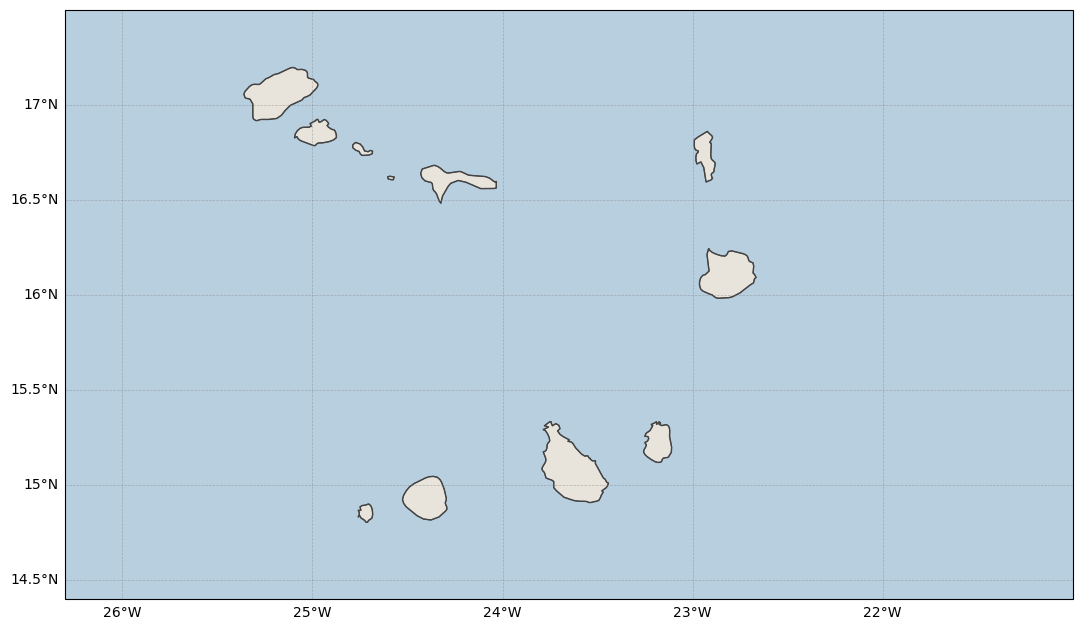

In [16]:
fig, ax = plt.subplots(figsize=(13, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-26.3, -21., 14.4, 17.5])
ax.set_facecolor("#b8cfe0")
ax.add_feature(cfeature.LAND, facecolor="#e8e4dc", edgecolor="#555", linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="#444")

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

print("Canvas ready — fig and ax created")

### Protected Area Polygons
Areas are grouped by type and plotted with distinct colors:
Marine > #2176ae (blue)
Coastal > #3a7d44 (green)
Polygons are semi‑transparent with black edges for clarity.

In [17]:
colors = {"marine": "#2176ae", "coastal": "#3a7d44"}

for t, data in gdf.groupby("type"):
    data.plot(ax=ax, transform=ccrs.PlateCarree(),
              facecolor=colors.get(t, "gray"), edgecolor="black",
              alpha=0.75, linewidth=0.8)

print("Polygons plotted")

Polygons plotted


### Label Configuration
Labels are manually positioned using absolute longitude/latitude coordinates to avoid overlap in tight clusters.
Each label is styled with:
White rounded box background
Subtle gray border
Arrow pointing to the polygon centroid

In [18]:
transform = ccrs.PlateCarree()._as_mpl_transform(ax)

label_config = {
    # ── Sal cluster
    "Reserva Natural Baía da Murdeira":      {"text_pos": (-23.55, 16.95), "ha": "left",   "va": "center"},
    "Reserva Natural Costa da Fragata":      {"text_pos": (-22.35, 16.85), "ha": "left",   "va": "center"},
    "Reserva Natural Serra Negra":           {"text_pos": (-22.35, 16.65), "ha": "left",   "va": "center"},
    "Reserva Natural Ponta de Sinó":         {"text_pos": (-22.35, 16.45), "ha": "left",   "va": "center"},
    # ── Santiago area
    "Parque Natural do Norte":               {"text_pos": (-23.55, 16.30), "ha": "left",   "va": "center"},
    "Reserva Natural Tartaruga":             {"text_pos": (-23.55, 16.05), "ha": "left",   "va": "center"},
    # ── Santa Luzia
    "Reserva Natural de Santa Luzia":        {"text_pos": (-24.74, 16.40), "ha": "center", "va": "center"},
    # ── Maio
    "Parque Natural Norte da Ilha do Maio":  {"text_pos": (-22.35, 15.31), "ha": "left",   "va": "center"},
}

print("Label config ready")

Label config ready


### Draw Annotations

In [19]:
for _, row in gdf.iterrows():
    cx, cy = row.geometry.centroid.coords[0]
    name   = row["name_eng"]
    cfg    = label_config.get(name)
    if cfg is None:
        continue
    tx, ty = cfg["text_pos"]

    ax.annotate(
        name,
        xy=(cx, cy), xycoords=transform,
        xytext=(tx, ty), textcoords=transform,
        fontsize=9, ha=cfg["ha"], va=cfg["va"],
        bbox=dict(facecolor="white", alpha=0.92, edgecolor="#888",
                  boxstyle="round,pad=0.35", linewidth=0.6),
        arrowprops=dict(arrowstyle="-", color="#333", lw=0.85,
                        shrinkA=3, shrinkB=3),
        zorder=12,
    )

print("Annotations drawn")

Annotations drawn


### Legend and Title
A legend explains the color coding of protected area types.
Positioned in the lower left with semi‑transparent background.

Saved to Downloads/cabo_verde_map_final.png


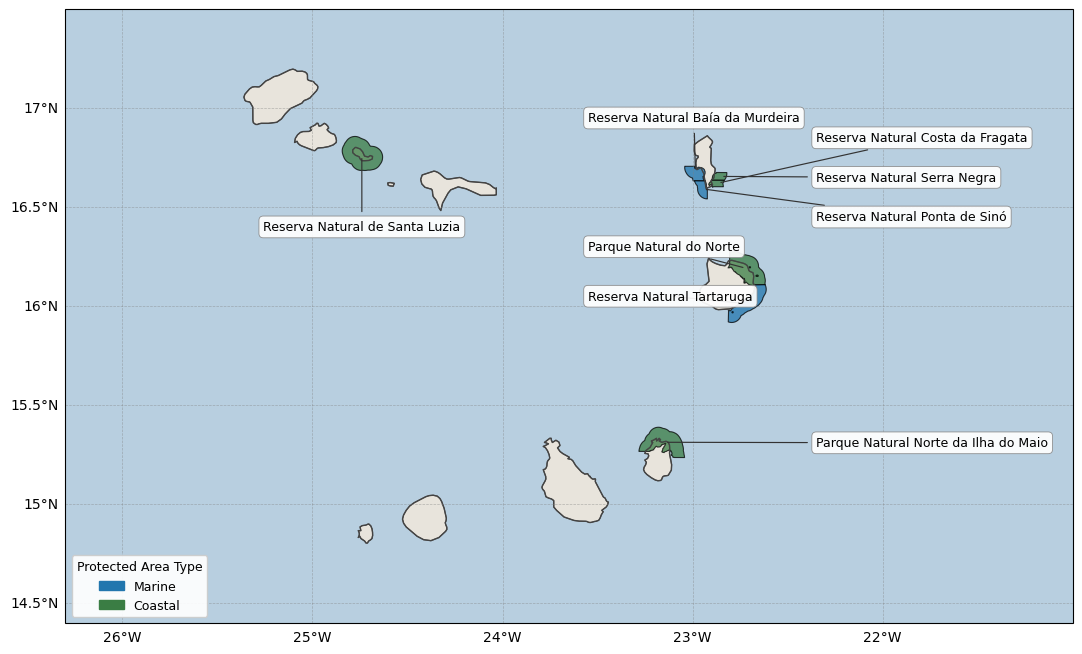

<Figure size 640x480 with 0 Axes>

In [20]:
ax.legend(
    handles=[mpatches.Patch(color="#2176ae", label="Marine"),
             mpatches.Patch(color="#3a7d44", label="Coastal")],
    title="Protected Area Type", loc="lower left",
    fontsize=9, title_fontsize=9, framealpha=0.92)

plt.tight_layout()
fig.savefig(r"C:\Users\LENOVO\Downloads\cabo_verde_map_final.png", dpi=200, bbox_inches="tight")
print("Saved to Downloads/cabo_verde_map_final.png")

display(fig)